In [2]:
#导入库
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#直接显示图表
%matplotlib inline

In [3]:
#数据读取
df  = pd.read_csv('Ecommerce_Sales_Data_2024_2025.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   object 
 2   Customer Name  5000 non-null   object 
 3   Region         5000 non-null   object 
 4   City           5000 non-null   object 
 5   Category       5000 non-null   object 
 6   Sub-Category   5000 non-null   object 
 7   Product Name   5000 non-null   object 
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 547.0+ KB


In [4]:
#数据处理
#判断是否存在缺失数据
print(df.isnull().sum())
#判断是否存在重复数据
print(df.duplicated().sum())
#数据概览
print(df.describe())


Order ID         0
Order Date       0
Customer Name    0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
dtype: int64
0
           Order ID     Quantity    Unit Price     Discount          Sales  \
count   5000.000000  5000.000000   5000.000000  5000.000000    5000.000000   
mean   12500.500000     2.992600  39760.904600    10.051000  106733.204870   
std     1443.520003     1.413133  22831.783946     7.084662   85108.208202   
min    10001.000000     1.000000    222.000000     0.000000     264.100000   
25%    11250.750000     2.000000  20312.250000     5.000000   39766.537500   
50%    12500.500000     3.000000  39459.500000    10.000000   83080.325000   
75%    13750.250000     4.000000  59721.750000    15.000000  156968.587500   
max    15000.000000     5.000000  79998.000000    20.000000  398485.000000   

             Pro

In [4]:
#定位“异常数据”判断该数据是否需要剔除
print('客单价最低的记录：')
print(df[df['Unit Price']==df['Unit Price'].min()])
print('\n'+'-'*80)
print('利润最低的记录：')
print(df[df['Profit']==df['Profit'].min()])

客单价最低的记录：
      Order ID Order Date Customer Name Region         City Category  \
3922     13923  2024/9/12   Khushi Iyer   East  Bhubaneswar     Toys   

     Sub-Category      Product Name  Quantity  Unit Price  Discount  Sales  \
3922       Puzzle  Puzzle Occaecati         3         222        15  566.1   

      Profit Payment Mode  
3922   97.74   Debit Card  

--------------------------------------------------------------------------------
利润最低的记录：
      Order ID Order Date    Customer Name Region   City   Category  \
3065     13066  2024/11/4  Gatik Chaudhary   East  Patna  Furniture   

     Sub-Category Product Name  Quantity  Unit Price  Discount  Sales  Profit  \
3065          Bed     Bed Esse         1         278         5  264.1   19.12   

     Payment Mode  
3065          UPI  


In [5]:
#将下单日期转换为日期格式
df['Order Date'] = pd.to_datetime(df['Order Date'])
#提取年份及月份
df['YearMonth'] = df['Order Date'].dt.to_period('M')
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
#查看数据基本情况
print(f"总行数：{len(df)}")
print(f"日期范围：{df['Order Date'].min()}至{df['Order Date'].max()}")
print("\n各品类销售额占比情况：")
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False))

总行数：5000
日期范围：2023-10-04 00:00:00至2025-10-03 00:00:00

各品类销售额占比情况：
Category
Home Decor     57233222.35
Furniture      56647187.90
Clothing       55053908.30
Books          54932643.00
Kitchen        54227902.30
Electronics    52587883.95
Toys           52227366.45
Sports         52069397.25
Beauty         50803409.70
Groceries      47883103.15
Name: Sales, dtype: float64


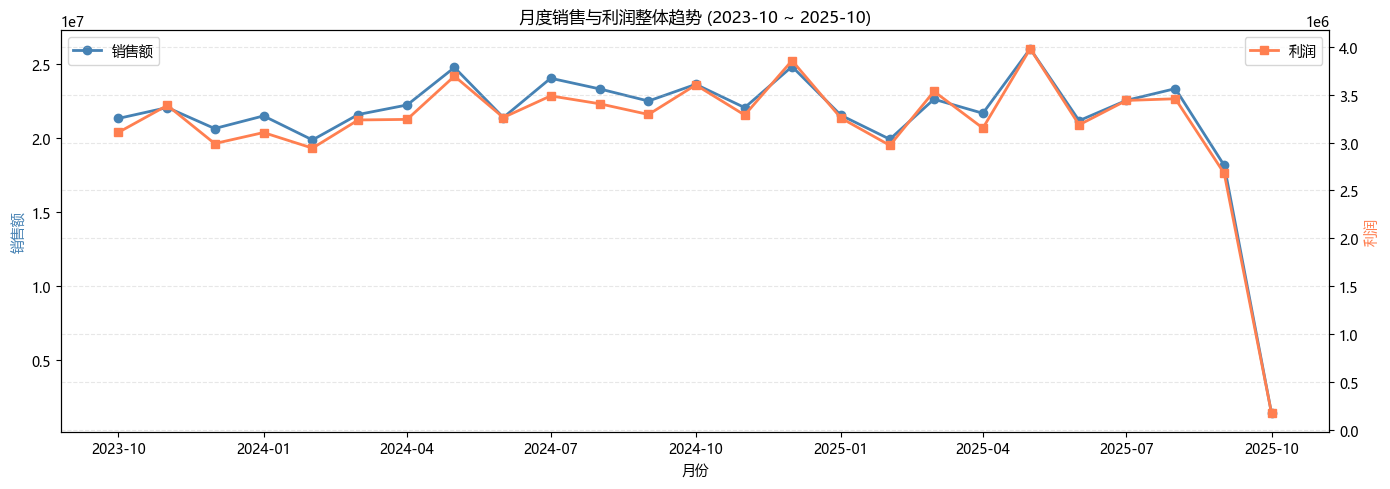

In [6]:
#销售趋势分析
#使用中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False 

#1、整体销售趋势分析
monthly_data =  (
    df.groupby(df['Order Date'].dt.to_period('M'))[['Sales', 'Profit']]
    .sum()
    .reset_index()
)
monthly_data['Order Date'] = monthly_data['Order Date'].dt.to_timestamp()



fig,ax1 = plt.subplots(figsize=(14,5))
ax2 = ax1.twinx()
ax1.plot(monthly_data['Order Date'], monthly_data['Sales'], color='steelblue', marker='o', linewidth=2, label='销售额')
ax2.plot(monthly_data['Order Date'], monthly_data['Profit'], color='coral', marker='s', linewidth=2, label='利润')

ax1.set_xlabel('月份')
ax1.set_ylabel('销售额', color='steelblue')
ax2.set_ylabel('利润', color='coral')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('月度销售与利润整体趋势 (2023-10 ~ 2025-10)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


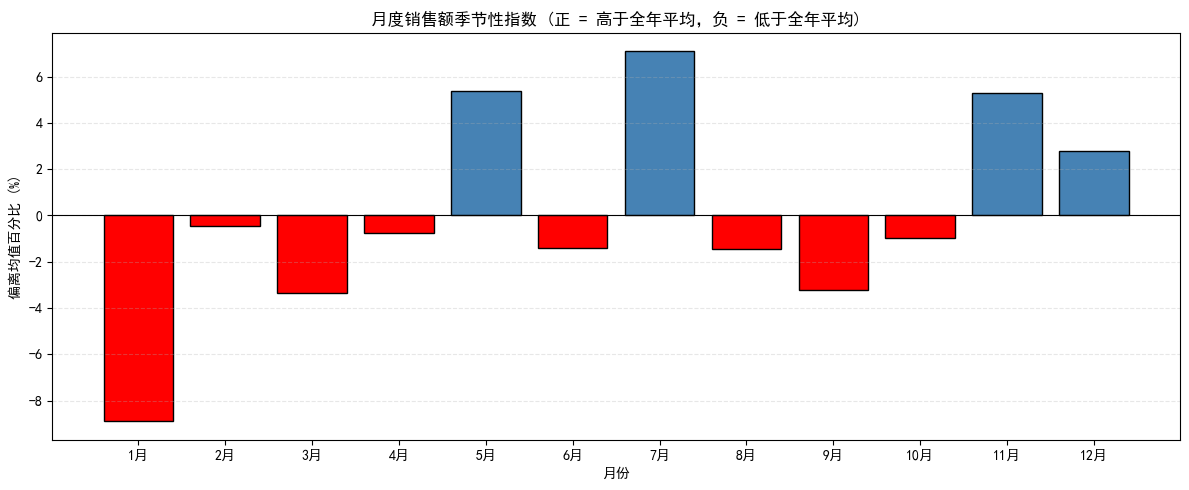

销售高峰期为: 7月 (比平均高 7.1%)
销售低谷期为: 1月 (比平均低 -8.9%)


In [66]:
#2.季节性销售趋势分析
monthly_pattern = df.groupby(df['Order Date'].dt.month)['Sales'].mean().reset_index()
monthly_pattern.columns = ['Month', 'Avg_Sales']

# 相对于全年平均的月度指数
avg_all = monthly_pattern['Avg_Sales'].mean()
monthly_pattern['Index'] = (monthly_pattern['Avg_Sales'] / avg_all - 1) * 100

# 柱状图绘制
colors = ['red' if x < 0 else 'steelblue' for x in monthly_pattern['Index']]
plt.figure(figsize=(12, 5))
plt.bar(monthly_pattern['Month'], monthly_pattern['Index'], color=colors, edgecolor='black')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('月份')
plt.ylabel('偏离均值百分比 (%)')
plt.title('月度销售额季节性指数 (正 = 高于全年平均，负 = 低于全年平均)')
plt.xticks(range(1, 13), ['1月','2月','3月','4月','5月','6月','7月','8月','9月','10月','11月','12月'])
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 结论
peak_month = monthly_pattern.loc[monthly_pattern['Index'].idxmax()]
trough_month = monthly_pattern.loc[monthly_pattern['Index'].idxmin()]
print(f"销售高峰期为: {int(peak_month['Month'])}月 (比平均高 {peak_month['Index']:.1f}%)")
print(f"销售低谷期为: {int(trough_month['Month'])}月 (比平均低 {trough_month['Index']:.1f}%)")

      Category        Sales      Profit  Profit_Margin
4    Furniture  56647187.90  8693087.03      15.346017
2     Clothing  55053908.30  8445750.29      15.340873
3  Electronics  52587883.95  8042133.88      15.292750
9         Toys  52227366.45  7986871.44      15.292503
6   Home Decor  57233222.35  8556846.94      14.950839
8       Sports  52069397.25  7739430.04      14.863683
5    Groceries  47883103.15  7075332.64      14.776262
1        Books  54932643.00  8076273.29      14.702139
7      Kitchen  54227902.30  7879573.29      14.530478
0       Beauty  50803409.70  7213436.07      14.198724


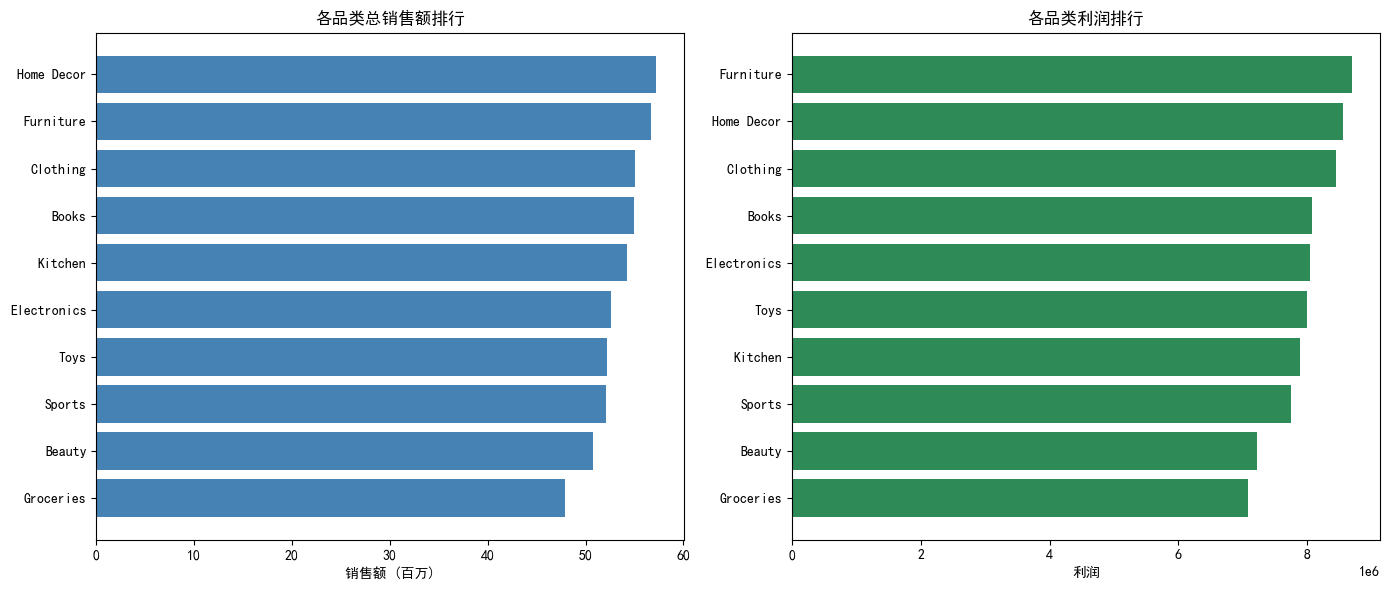

In [94]:
#品类总体分析
#按品类分析销售额、利润、利润率及销量
category_performance = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Order ID': 'count'
}).reset_index()

category_performance['Profit_Margin'] = (category_performance['Profit'] / category_performance['Sales']) * 100
category_performance = category_performance.sort_values('Profit_Margin', ascending=False)

print(category_performance[['Category', 'Sales', 'Profit', 'Profit_Margin']].head(10))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
#销售额排行
sales_rank = category_performance.sort_values('Sales', ascending=True)
axes[0].barh(sales_rank['Category'], sales_rank['Sales'] / 1e6, color='steelblue')
axes[0].set_xlabel('销售额 (百万)')
axes[0].set_title('各品类总销售额排行')

#利润排行
Profit_rank = category_performance.sort_values('Profit', ascending=True)
colors = ['coral' if x < 10 else 'seagreen' for x in margin_rank['Profit']]
axes[1].barh(Profit_rank['Category'], Profit_rank['Profit'], color=colors)
axes[1].set_xlabel('利润')
axes[1].set_title('各品类利润排行')

plt.tight_layout()
plt.show()


HHI 指数: 0.1003
前 1 大品类累计占比: 10.7%
前 3 大品类累计占比: 31.7%
前 5 大品类累计占比: 52.1%


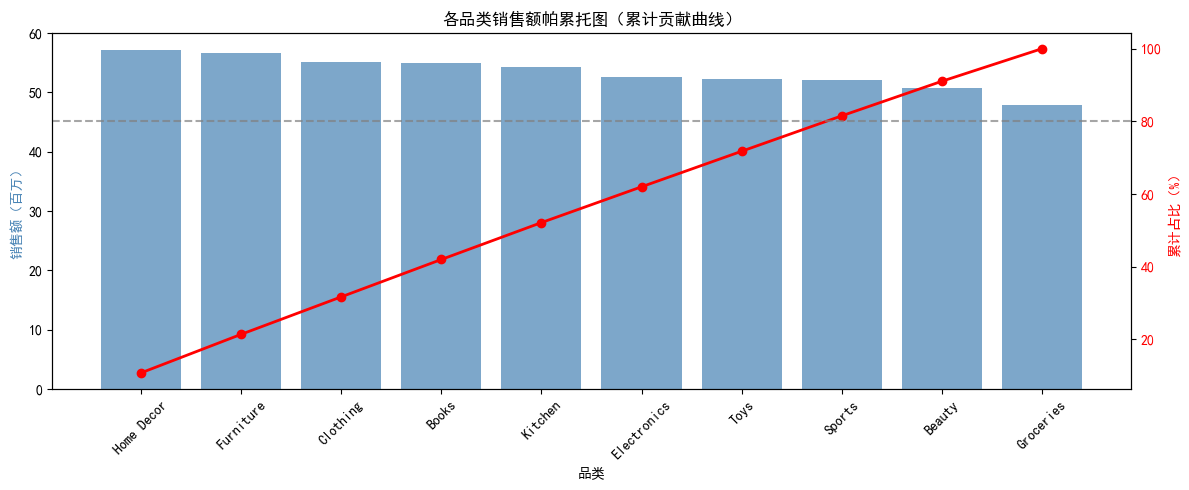

In [98]:
# 计算各品类销售额占比
category_share = df.groupby('Category')['Sales'].sum() / df['Sales'].sum()

# HHI 指数（赫芬达尔-赫希曼指数）
hhi = (category_share ** 2).sum()
print(f"HHI 指数: {hhi:.4f}")

# 累计占比曲线（帕累托图）
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_share = category_sales / category_sales.sum()

cumsum = category_share.cumsum()

print(f"前 1 大品类累计占比: {cumsum.iloc[0]:.1%}")
print(f"前 3 大品类累计占比: {cumsum.iloc[2]:.1%}")
print(f"前 5 大品类累计占比: {cumsum.iloc[4]:.1%}")

fig, ax1 = plt.subplots(figsize=(12, 5))


ax1.bar(category_sales.index, category_sales.values / 1e6, color='steelblue', alpha=0.7)
ax1.set_xlabel('品类')
ax1.set_ylabel('销售额（百万）', color='steelblue')
ax1.tick_params(axis='x', rotation=45)


ax2 = ax1.twinx()
ax2.plot(category_sales.index, cumsum.values * 100, color='red', marker='o', linewidth=2)
ax2.set_ylabel('累计占比（%）', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# 80% 参考线
ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.7, label='80% 线')

plt.title('各品类销售额帕累托图（累计贡献曲线）')
plt.tight_layout()
plt.show()

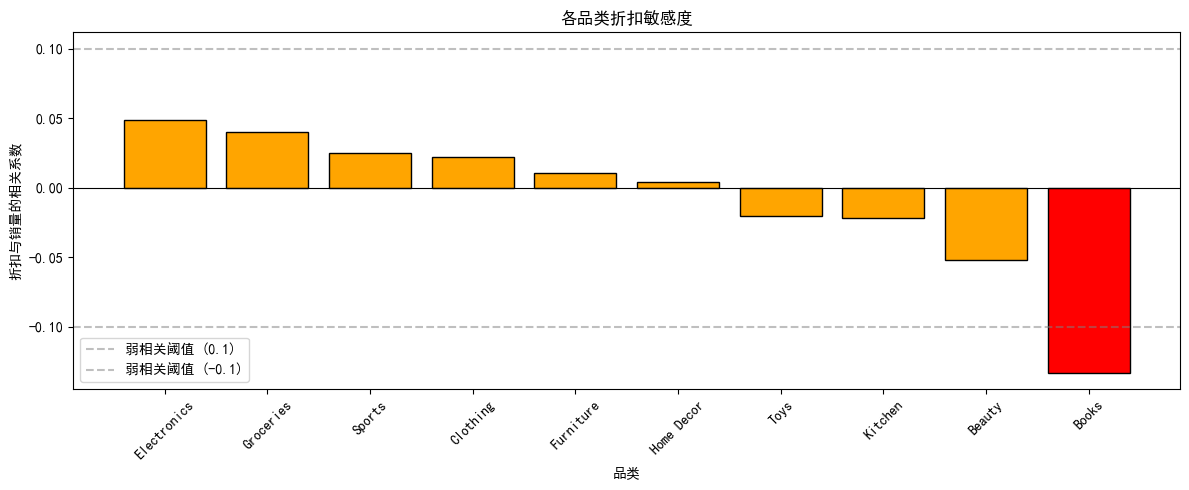

In [101]:
#品类折扣敏感度
sensitivity = []
for cat in df['Category'].unique():
    sub = df[df['Category'] == cat]
    if len(sub) > 30:
        corr = sub['Discount'].corr(sub['Quantity'])
        sensitivity.append({
            'Category': cat,
            'Correlation': corr,
            'Avg_Discount': sub['Discount'].mean(),
            'Order_Count': len(sub)
        })

sens_df = pd.DataFrame(sensitivity).sort_values('Correlation', ascending=False)
# 2. 画柱状图
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['green' if x > 0.1 else 'orange' if x > -0.1 else 'red' for x in sens_df['Correlation']]
ax.bar(sens_df['Category'], sens_df['Correlation'], color=colors, edgecolor='black')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, label='弱相关阈值 (0.1)')
ax.axhline(y=-0.1, color='gray', linestyle='--', alpha=0.5, label='弱相关阈值 (-0.1)')

ax.set_xlabel('品类')
ax.set_ylabel('折扣与销量的相关系数')
ax.set_title('各品类折扣敏感度')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

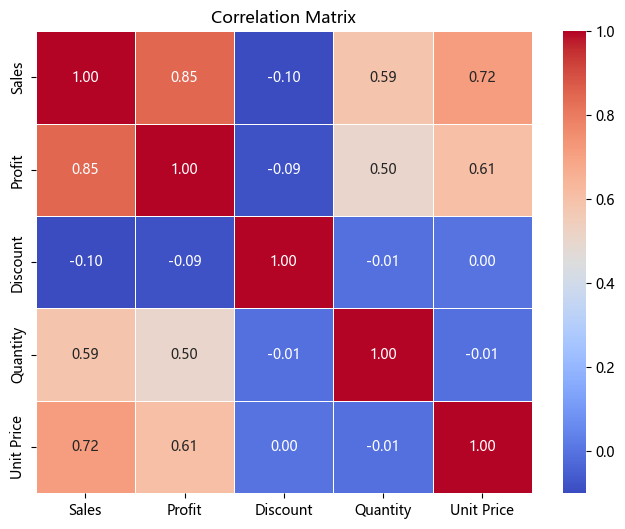

In [27]:
#相关性分析
corr_matrix = df[['Sales', 'Profit', 'Discount', 'Quantity', 'Unit Price']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [14]:
#地区表现分析
#地区汇总
region_summary = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'count',
    'Quantity': 'sum'
}).reset_index()

region_summary['Profit_Margin'] = (region_summary['Profit'] / region_summary['Sales']) * 100
region_summary = region_summary.sort_values('Sales', ascending=False)

print("各地区表现汇总")
print(region_summary.to_string(float_format=lambda x: f'{x:,.2f}'))



各地区表现汇总
  Region          Sales        Profit  Order ID  Quantity  Profit_Margin
1  North 143,578,246.10 21,343,004.33      1288      3949          14.87
0   East 135,811,637.95 20,532,558.12      1256      3823          15.12
3   West 131,045,973.35 19,580,123.14      1241      3685          14.94
2  South 123,230,166.95 18,253,049.32      1215      3506          14.81


销售额方差分析结果: F统计量 = 3.0985, p值 = 0.0256988604
利润方差分析结果: F统计量 = 2.6687, p值 = 0.0460035973


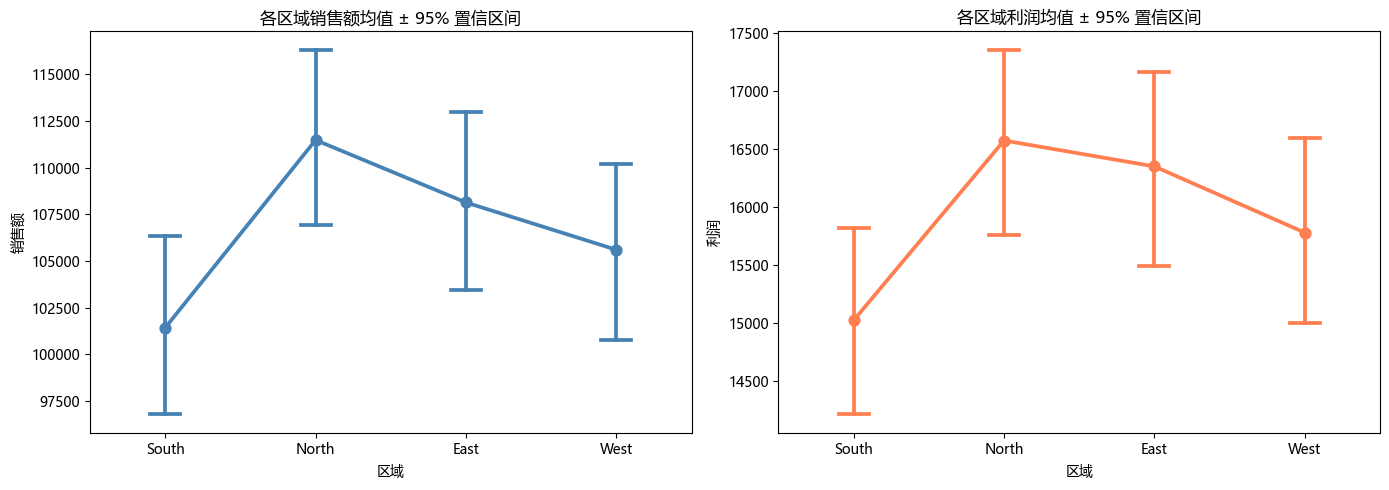

In [15]:
#方差分析
#不同地区销售额、利润是否存在显著差异
from scipy.stats import f_oneway

groups1 = [df[df['Region'] == cat]['Sales'].values for cat in df['Region'].unique()]
f_stat1, p_value1 = f_oneway(*groups1)
print(f"销售额方差分析结果: F统计量 = {f_stat1:.4f}, p值 = {p_value1:.10f}")

groups2 = [df[df['Region'] == cat]['Profit'].values for cat in df['Region'].unique()]
f_stat2, p_value2 = f_oneway(*groups2)
print(f"利润方差分析结果: F统计量 = {f_stat2:.4f}, p值 = {p_value2:.10f}")
#绘制置信区间
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.pointplot(data=df, x='Region', y='Sales', ax=axes[0], 
              capsize=0.2, errorbar='ci', color='steelblue')
axes[0].set_title('各区域销售额均值 ± 95% 置信区间')
axes[0].set_xlabel('区域')
axes[0].set_ylabel('销售额')

sns.pointplot(data=df, x='Region', y='Profit', ax=axes[1], 
              capsize=0.2, errorbar='ci', color='coral')
axes[1].set_title('各区域利润均值 ± 95% 置信区间')
axes[1].set_xlabel('区域')
axes[1].set_ylabel('利润')

plt.tight_layout()
plt.show()

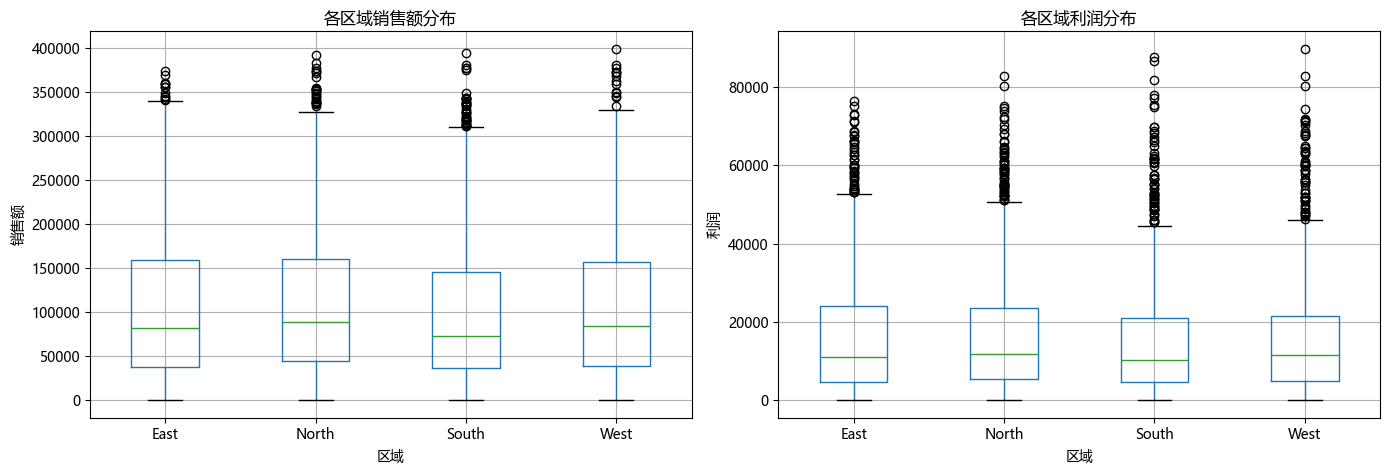

In [16]:
#箱线图绘制
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 销售额箱线图
df.boxplot(column='Sales', by='Region', ax=axes[0])
axes[0].set_title('各区域销售额分布')
axes[0].set_xlabel('区域')
axes[0].set_ylabel('销售额')

# 利润箱线图
df.boxplot(column='Profit', by='Region', ax=axes[1])
axes[1].set_title('各区域利润分布')
axes[1].set_xlabel('区域')
axes[1].set_ylabel('利润')

plt.suptitle('')  
plt.tight_layout()
plt.show()

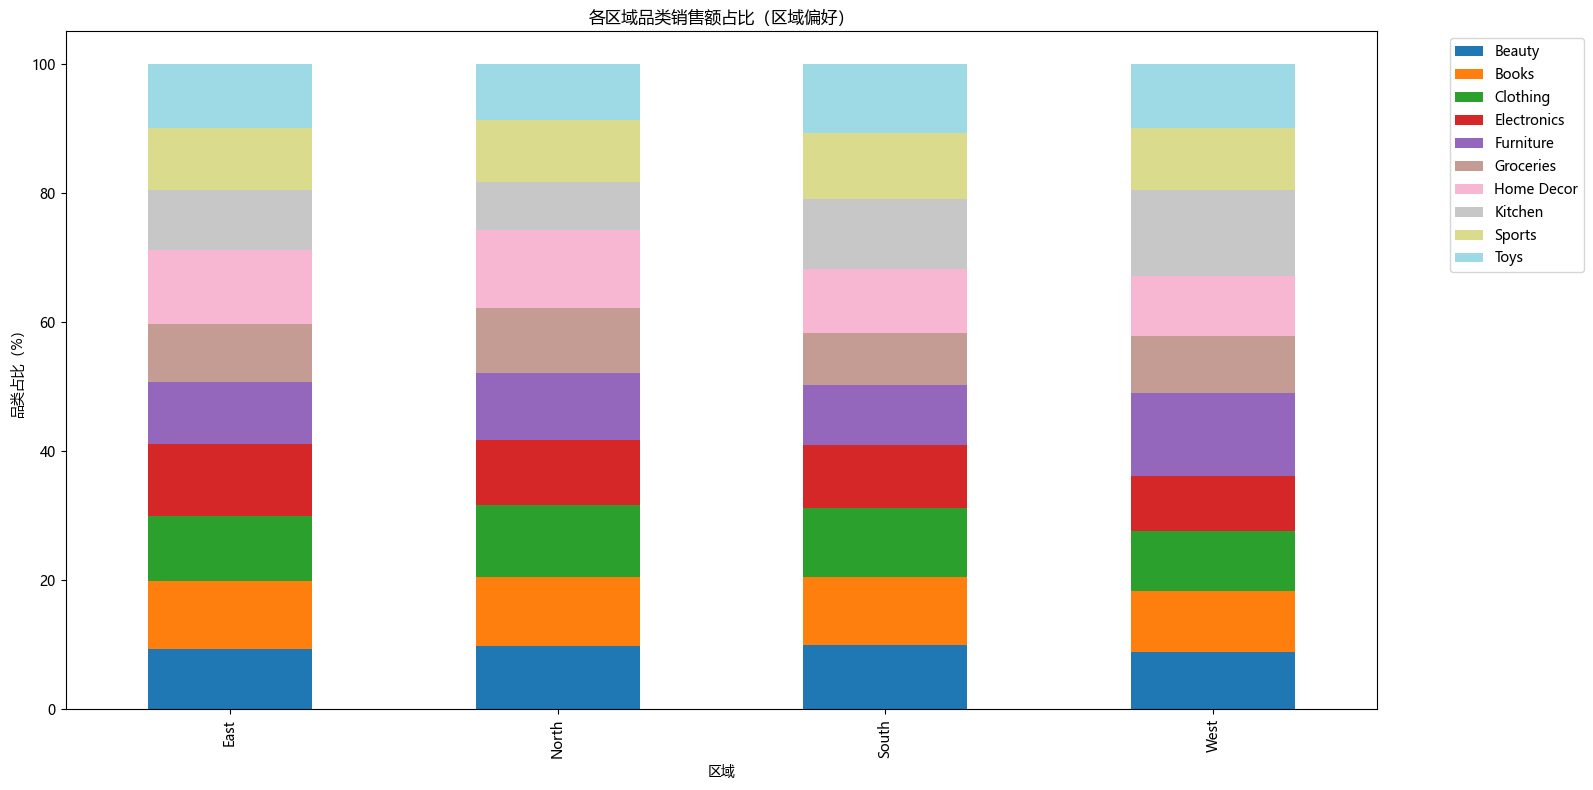

In [8]:
# 区域 × 品类 交叉表（销售额占比）
region_cat = df.groupby(['Region', 'Category'])['Sales'].sum().unstack().fillna(0)
region_cat_pct = region_cat.div(region_cat.sum(axis=1), axis=0) * 100

# 画堆叠柱状图
region_cat_pct.plot(kind='bar', stacked=True, figsize=(16, 8), colormap='tab20')
plt.title('各区域品类销售额占比（区域偏好）')
plt.xlabel('区域')
plt.ylabel('品类占比（%）')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [55]:
print(region_cat_pct)

Category    Beauty      Books   Clothing  Electronics  Furniture  Groceries  \
Region                                                                        
East      9.417752  10.436038  10.076452    11.166862   9.638481   8.900818   
North     9.740271  10.755038  11.095399    10.056951  10.507007   9.999431   
South     9.975020  10.507780  10.761616     9.641185   9.393241   8.059349   
West      8.955530   9.438397   9.291989     8.471489  12.893128   8.780277   

Category  Home Decor    Kitchen     Sports       Toys  
Region                                                 
East       11.478885   9.369150   9.546081   9.969480  
North      12.039953   7.508852   9.579504   8.717594  
South       9.806018  10.873321  10.296028  10.686442  
West        9.365290  13.219190   9.662877   9.921834  


In [11]:
# 统计每个区域包含多少个城市
region_city_count = df.groupby('Region')['City'].nunique().sort_values(ascending=False)
print("各区域城市数量：")
print(region_city_count)

各区域城市数量：
Region
East     5
North    5
South    5
West     5
Name: City, dtype: int64


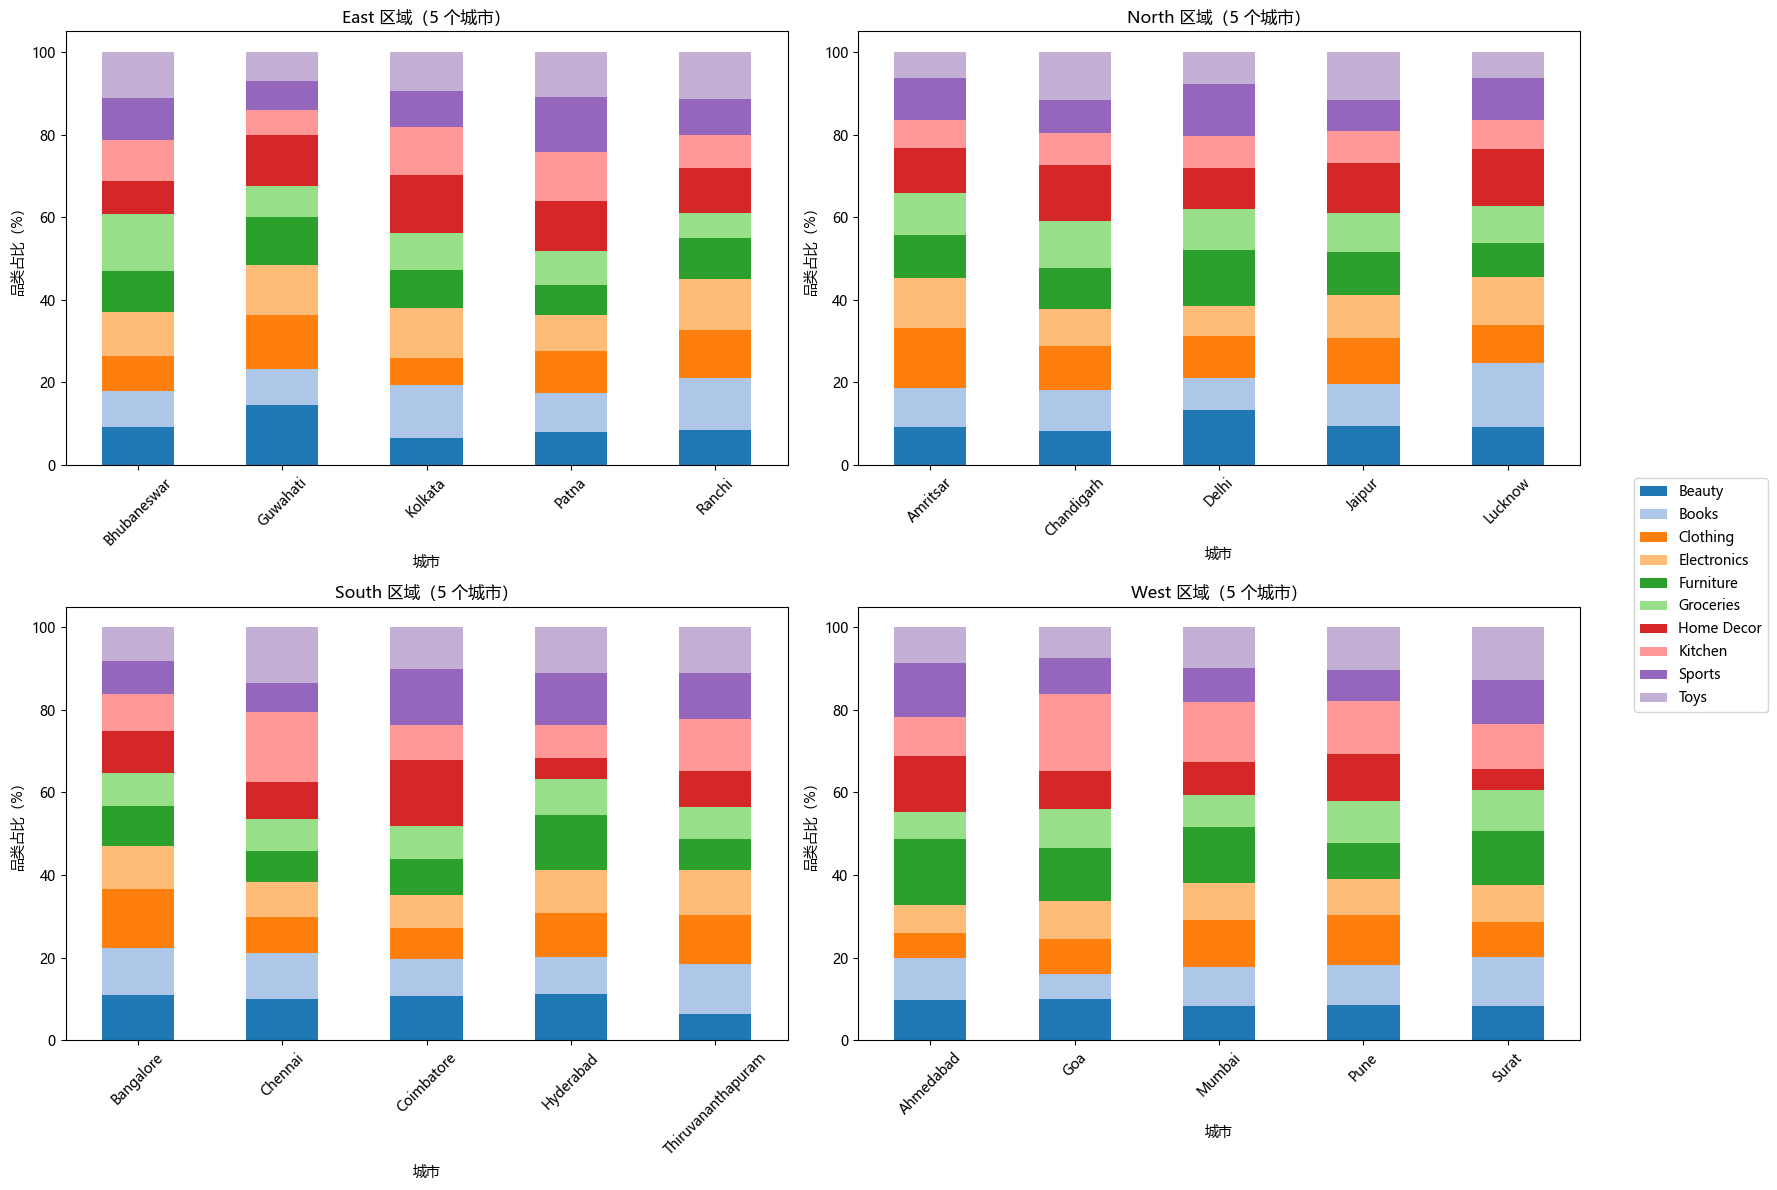

In [12]:
region_cities = df.groupby('Region')['City'].unique()

# 3. 画图：4个子图（每个区域一个），每个子图展示该区域5个城市的品类占比
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# 统一颜色
categories = df['Category'].unique()
colors = plt.cm.tab20.colors[:len(categories)]

for i, region in enumerate(region_cities.index):
    cities = region_cities[region]
    # 城市 × 品类 交叉表（占比）
    city_cat = df[df['City'].isin(cities)].groupby(['City', 'Category'])['Sales'].sum().unstack().fillna(0)
    city_cat_pct = city_cat.div(city_cat.sum(axis=1), axis=0) * 100
    
    # 画堆叠柱状图
    city_cat_pct.plot(kind='bar', stacked=True, ax=axes[i], color=colors, legend=False)
    axes[i].set_title(f'{region} 区域（{len(cities)} 个城市）')
    axes[i].set_xlabel('城市')
    axes[i].set_ylabel('品类占比（%）')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend().remove()

# 统一图例放在右侧
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 0.5), loc='center left', fontsize=10)
plt.tight_layout()
plt.show()

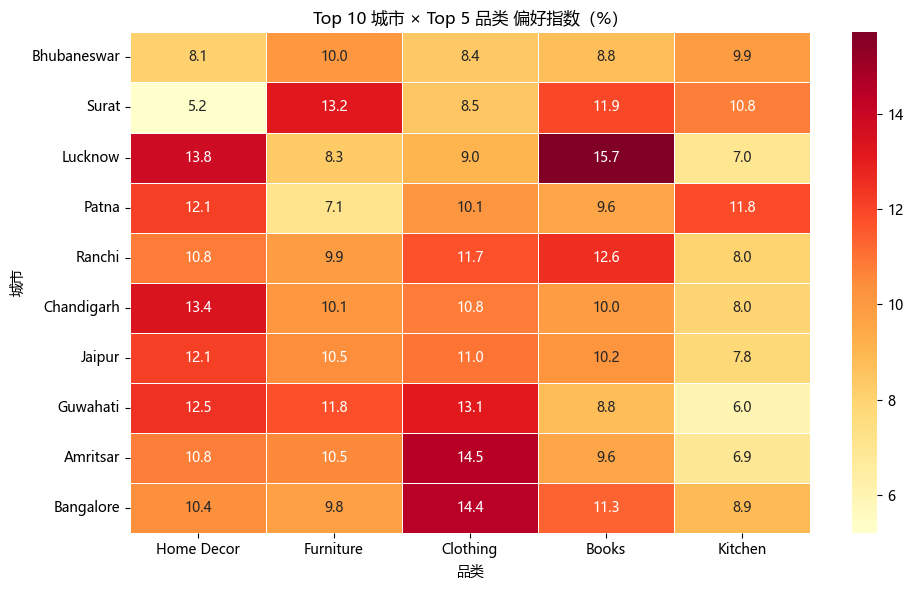

In [13]:
# Top 10 城市 × Top 5 品类
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10).index
top_cats = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).head(5).index

# 交叉表：城市 × 品类
city_cat = df[df['City'].isin(top_cities)].groupby(['City', 'Category'])['Sales'].sum().unstack().fillna(0)
city_cat_pct = city_cat.div(city_cat.sum(axis=1), axis=0) * 100  # 每个城市内品类占比

# 只保留 Top 5 品类
city_cat_pct = city_cat_pct[top_cats]

# 按偏好排序（让相近的城市排在一起）
from scipy.cluster.hierarchy import linkage, leaves_list

# 聚类排序（让相似的城市相邻）
linkage_matrix = linkage(city_cat_pct, method='average')
order = leaves_list(linkage_matrix)
city_cat_pct = city_cat_pct.iloc[order]
# 画热力图
plt.figure(figsize=(10, 6))
sns.heatmap(city_cat_pct, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Top 10 城市 × Top 5 品类 偏好指数（%）')
plt.xlabel('品类')
plt.ylabel('城市')
plt.tight_layout()
plt.show()

In [58]:
print(top_cities)
print('\n')
print(top_cats)

Index(['Bangalore', 'Lucknow', 'Guwahati', 'Chandigarh', 'Jaipur', 'Amritsar',
       'Surat', 'Patna', 'Bhubaneswar', 'Ranchi'],
      dtype='object', name='City')


Index(['Home Decor', 'Furniture', 'Clothing', 'Books', 'Kitchen'], dtype='object', name='Category')



支付方式表现汇总
  Payment Mode          Sales        Profit  Order ID  Profit_Margin  Avg_Order_Value
3  Net Banking 111,465,516.05 16,964,119.74      1010          15.22       110,361.90
0          COD 108,881,396.25 16,575,845.53      1005          15.22       108,339.70
1  Credit Card 106,027,144.90 15,658,639.35       994          14.77       106,667.15
2   Debit Card 105,346,381.65 15,479,323.07      1003          14.69       105,031.29
4          UPI 101,945,585.50 15,030,807.22       988          14.74       103,183.79


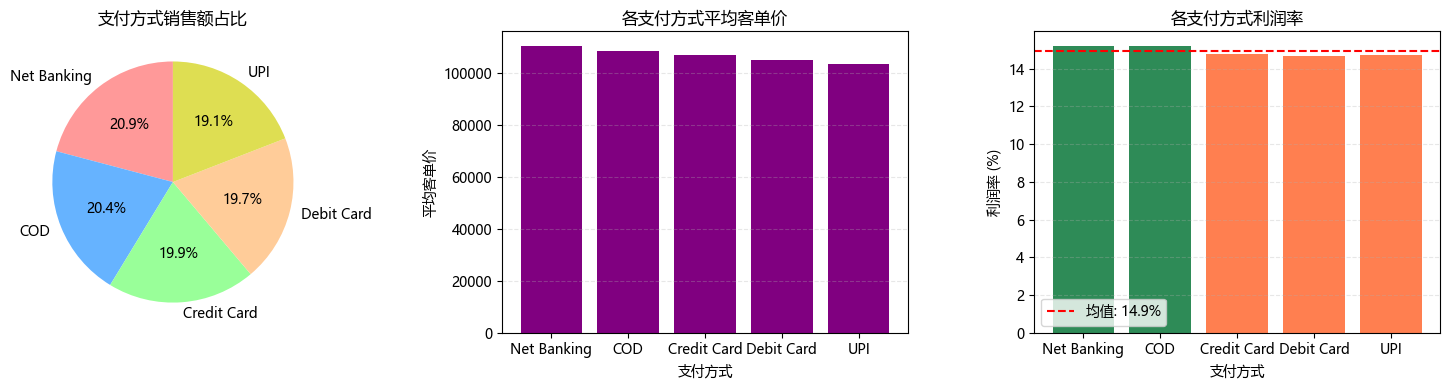

In [39]:
#支付方式分析
payment_summary = df.groupby('Payment Mode').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'count'
}).reset_index()

payment_summary['Profit_Margin'] = (payment_summary['Profit'] / payment_summary['Sales']) * 100
payment_summary['Avg_Order_Value'] = payment_summary['Sales'] / payment_summary['Order ID']
payment_summary = payment_summary.sort_values('Sales', ascending=False)

print("\n支付方式表现汇总")
print(payment_summary.to_string(float_format=lambda x: f'{x:,.2f}'))

#
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 支付方式销售额占比
axes[0].pie(payment_summary['Sales'], labels=payment_summary['Payment Mode'], 
            autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#DEDE52'])
axes[0].set_title('支付方式销售额占比')

# 支付方式平均客单价
axes[1].bar(payment_summary['Payment Mode'], payment_summary['Avg_Order_Value'], color='purple')
axes[1].set_xlabel('支付方式')
axes[1].set_ylabel('平均客单价')
axes[1].set_title('各支付方式平均客单价')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

# 支付方式利润率
colors = ['seagreen' if x >= payment_summary['Profit_Margin'].mean() else 'coral' 
          for x in payment_summary['Profit_Margin']]
axes[2].bar(payment_summary['Payment Mode'], payment_summary['Profit_Margin'], color=colors)
axes[2].axhline(y=payment_summary['Profit_Margin'].mean(), color='red', linestyle='--', 
                label=f'均值: {payment_summary["Profit_Margin"].mean():.1f}%')
axes[2].set_xlabel('支付方式')
axes[2].set_ylabel('利润率 (%)')
axes[2].set_title('各支付方式利润率')
axes[2].legend()
axes[2].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [70]:
#时间序列预测销售趋势
#导入库
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

#数据处理
#检查月份是否连续
monthly_sales = df.groupby('YearMonth')['Sales'].sum()
monthly_sales.index = monthly_sales.index.astype(str)

   Order Date        Sales      Profit
14 2024-12-01  24806786.40  3855729.92
15 2025-01-01  21520801.80  3255994.46
16 2025-02-01  19902446.10  2970431.02
17 2025-03-01  22602988.75  3533884.47
18 2025-04-01  21653817.90  3150564.23
19 2025-05-01  26010928.65  3979356.67
20 2025-06-01  21155496.20  3184539.18
21 2025-07-01  22526567.55  3439384.07
22 2025-08-01  23317916.20  3456953.24
23 2025-09-01  18131496.70  2677363.66
总月份数: 24


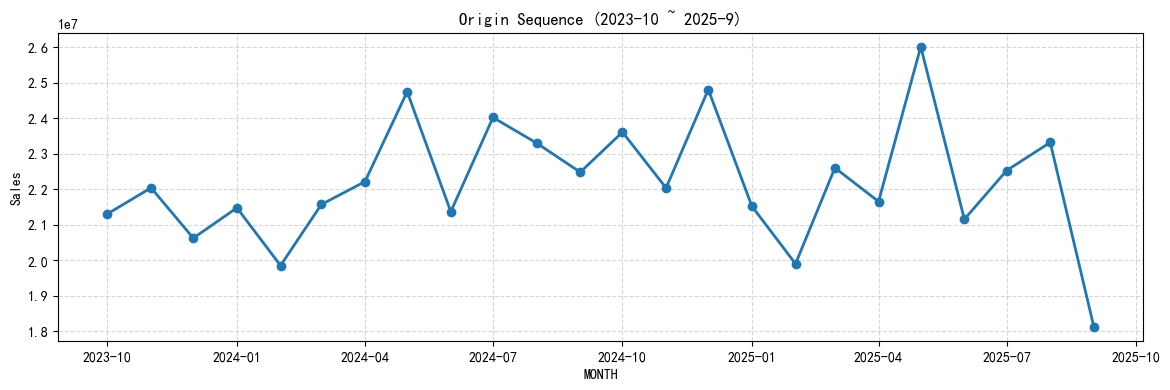

In [71]:
monthly_sales = df_ts.groupby(df_ts['Order Date'].dt.to_period('M'))[['Sales', 'Profit']].sum().reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()

print(monthly_sales.tail(10))
print(f"总月份数: {len(monthly_sales)}") 
# 画原始序列
plt.figure(figsize=(14, 4))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], marker='o', linewidth=2)
plt.title('Origin Sequence (2023-10 ~ 2025-9)')
plt.xlabel('MONTH')
plt.ylabel('Sales')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [72]:
# 用前 18 个月训练，后 6 个月测试
train = monthly_sales.iloc[:-6]
test = monthly_sales.iloc[-6:]

print(f"训练集: {train['Order Date'].min()} ~ {train['Order Date'].max()} ({len(train)}个月)")
print(f"测试集: {test['Order Date'].min()} ~ {test['Order Date'].max()} ({len(test)}个月)")

训练集: 2023-10-01 00:00:00 ~ 2025-03-01 00:00:00 (18个月)
测试集: 2025-04-01 00:00:00 ~ 2025-09-01 00:00:00 (6个月)


ETS   MAE: 2,210,325.40 RMSE: 2,612,218.03
预测值: [23331163.0, 23900387.0, 23653877.0, 23913898.0, 22747788.0, 23149722.0]


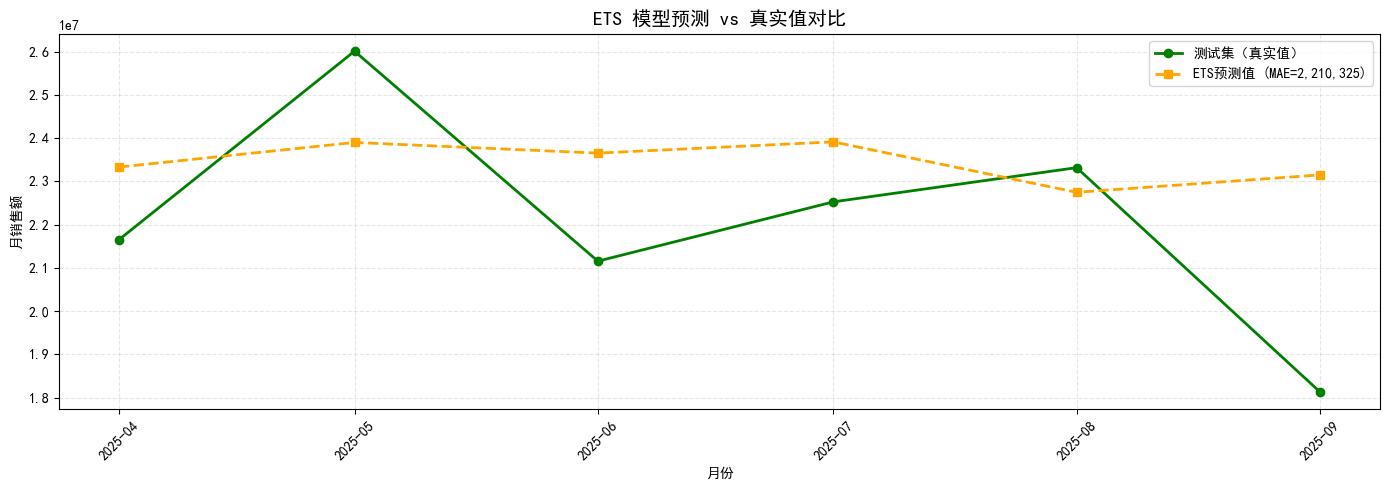

In [79]:
#ETS 模型
ets_model = ExponentialSmoothing(
    train['Sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=6
).fit(use_brute=False)  

ets_forecast = ets_model.forecast(6)
ets_mae = mean_absolute_error(test['Sales'], ets_forecast)
ets_rmse = np.sqrt(mean_squared_error(test['Sales'], ets_forecast))
print(f"ETS   MAE: {ets_mae:,.2f} RMSE: {ets_rmse:,.2f}")
print(f"预测值: {ets_forecast.round(0).tolist()}")

plt.figure(figsize=(14, 5))

# 测试集真实值
plt.plot(test['Order Date'], test['Sales'], 
         label='测试集（真实值）', color='green', marker='o', linewidth=2)

# ETS 预测值
plt.plot(test['Order Date'], ets_forecast, 
         label=f'ETS预测值 (MAE={ets_mae:,.0f})', 
         color='orange', linestyle='--', marker='s', linewidth=2)

plt.title('ETS 模型预测 vs 真实值对比', fontsize=14)
plt.xlabel('月份')
plt.ylabel('月销售额')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [80]:
for i in range(len(test)):
    month = test.iloc[i]['Order Date'].strftime('%Y-%m')
    actual = test.iloc[i]['Sales']
    pred = ets_forecast.iloc[i]
    diff = pred - actual
    pct = (diff / actual) * 100
    print(f"{month}: 真实={actual:,.0f}, 预测={pred:,.0f}, 偏差={diff:,.0f} ({pct:+.1f}%)")

2025-04: 真实=21,653,818, 预测=23,331,163, 偏差=1,677,345 (+7.7%)
2025-05: 真实=26,010,929, 预测=23,900,387, 偏差=-2,110,541 (-8.1%)
2025-06: 真实=21,155,496, 预测=23,653,877, 偏差=2,498,381 (+11.8%)
2025-07: 真实=22,526,568, 预测=23,913,898, 偏差=1,387,331 (+6.2%)
2025-08: 真实=23,317,916, 预测=22,747,788, 偏差=-570,128 (-2.4%)
2025-09: 真实=18,131,497, 预测=23,149,722, 偏差=5,018,225 (+27.7%)


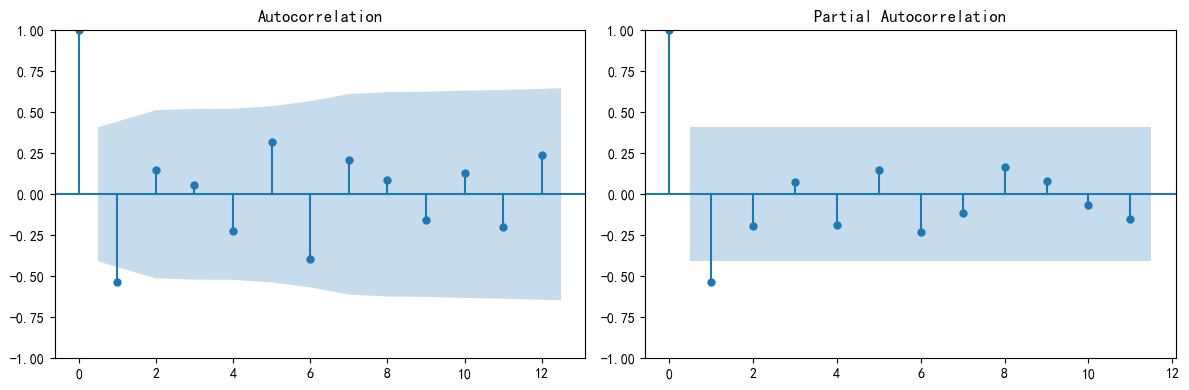

In [75]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# 确保 monthly_sales 是 24 个月完整数据
monthly_sales_clean = monthly_sales[monthly_sales['Order Date'] < '2025-10-01']

sales_series = monthly_sales_clean.set_index('Order Date')['Sales']
sales_diff = sales_series.diff().dropna()

# 画 ACF 和 PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(sales_diff, ax=axes[0], lags=12)
plot_pacf(sales_diff, ax=axes[1], lags=11)
plt.tight_layout()
plt.show()

ARIMA(1,1,1) MAE: 1,825,031.36
预测值: [22517837.0, 22486060.0, 22474201.0, 22469775.0, 22468124.0, 22467508.0]


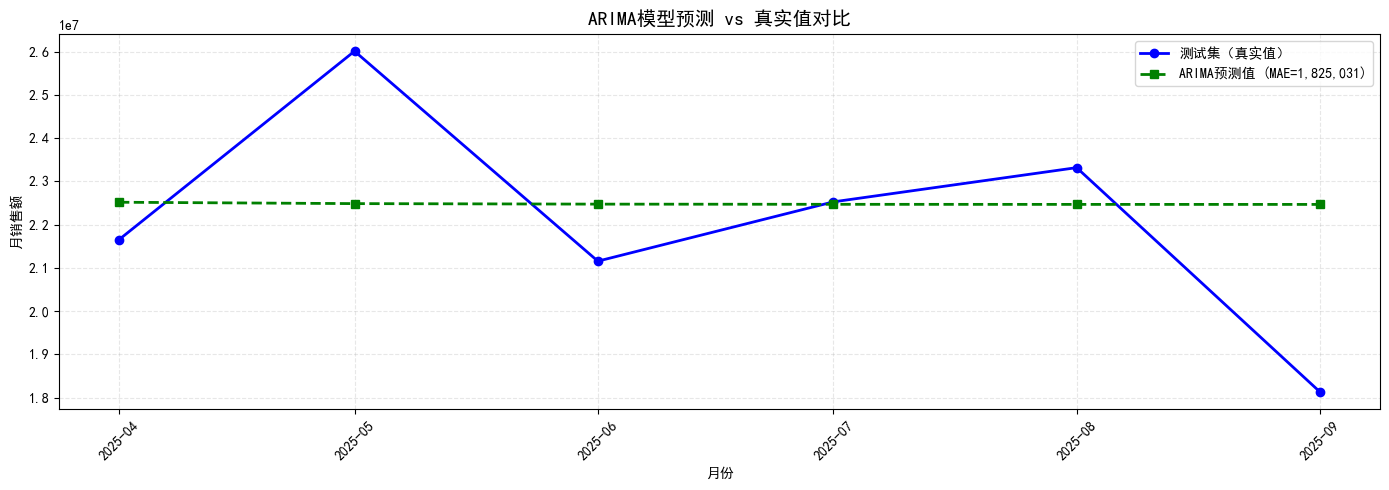

2025-04: 真实=21,653,818, 预测=22,517,837, 偏差=864,019 (+4.0%)
2025-05: 真实=26,010,929, 预测=22,486,060, 偏差=-3,524,869 (-13.6%)
2025-06: 真实=21,155,496, 预测=22,474,201, 偏差=1,318,705 (+6.2%)
2025-07: 真实=22,526,568, 预测=22,469,775, 偏差=-56,792 (-0.3%)
2025-08: 真实=23,317,916, 预测=22,468,124, 偏差=-849,792 (-3.6%)
2025-09: 真实=18,131,497, 预测=22,467,508, 偏差=4,336,011 (+23.9%)


In [89]:
#ARIMA
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train['Sales'], order=(1, 1, 1)).fit()
arima_forecast = arima_model.forecast(6)
arima_mae = mean_absolute_error(test['Sales'], arima_forecast)


print(f"ARIMA(1,1,1) MAE: {arima_mae:,.2f}")
print(f"预测值: {arima_forecast.round(0).tolist()}")

plt.figure(figsize=(14, 5))

# 测试集真实值
plt.plot(test['Order Date'], test['Sales'], 
         label='测试集（真实值）', color='blue', marker='o', linewidth=2)

# ARIMA预测值
plt.plot(test['Order Date'], arima_forecast, 
         label=f'ARIMA预测值 (MAE={arima_mae:,.0f})', 
         color='green', linestyle='--', marker='s', linewidth=2)

plt.title('ARIMA模型预测 vs 真实值对比', fontsize=14)
plt.xlabel('月份')
plt.ylabel('月销售额')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

for i in range(len(test)):
    month = test.iloc[i]['Order Date'].strftime('%Y-%m')
    actual = test.iloc[i]['Sales']
    pred = arima_forecast.iloc[i]
    diff = pred - actual
    pct = (diff / actual) * 100
    print(f"{month}: 真实={actual:,.0f}, 预测={pred:,.0f}, 偏差={diff:,.0f} ({pct:+.1f}%)")

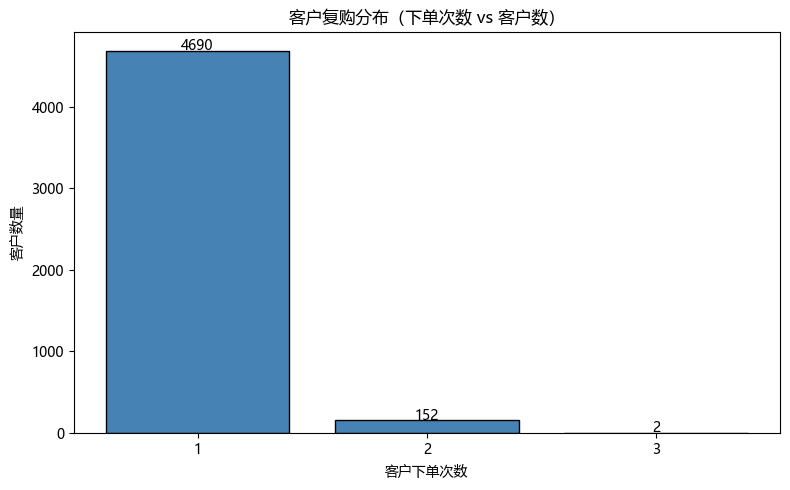

复购率: 3.2%
单次客户: 4690
复购客户: 154


In [37]:
#用户行为分析
# 复购分布
cust_orders = df.groupby('Customer Name').size().reset_index(name='Order_Count')
order_dist = cust_orders['Order_Count'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(order_dist.index.astype(str), order_dist.values, color='steelblue', edgecolor='black')
plt.xlabel('客户下单次数')
plt.ylabel('客户数量')
plt.title('客户复购分布（下单次数 vs 客户数）')
for i, v in enumerate(order_dist.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# 复购率
repeat_rate = (cust_orders['Order_Count'] > 1).sum() / len(cust_orders) * 100
print(f"复购率: {repeat_rate:.1f}%")
print(f"单次客户: {(cust_orders['Order_Count'] == 1).sum()}")
print(f"复购客户: {(cust_orders['Order_Count'] > 1).sum()}")

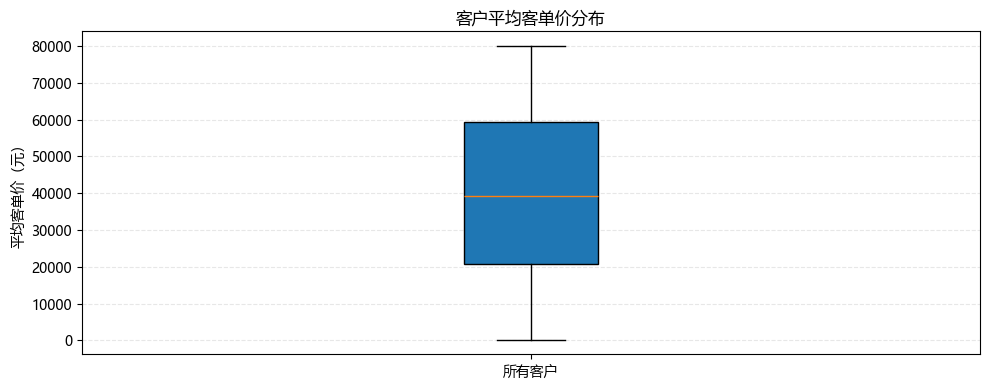

In [59]:
# 每个客户的平均客单价
cust_avg = df.groupby('Customer Name')['Unit Price'].mean().reset_index(name='Avg_Order_Value')

plt.figure(figsize=(10, 4))
plt.boxplot(cust_avg['Avg_Order_Value'], vert=True, patch_artist=True)
plt.ylabel('平均客单价（元）')
plt.title('客户平均客单价分布')
plt.xticks([1], ['所有客户'])
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

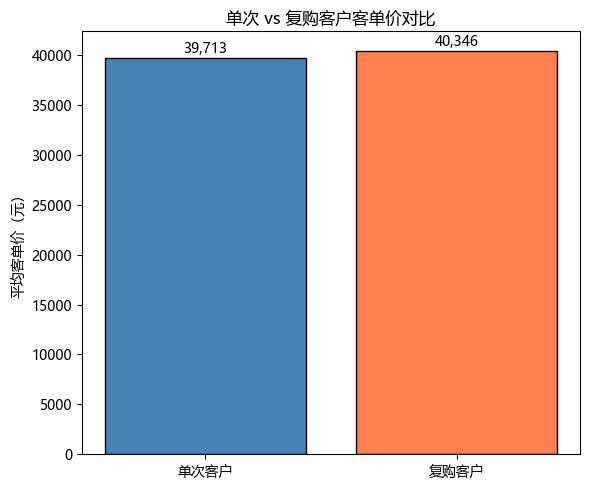

In [60]:
# 标记是否复购
cust_orders['Is_Repeat'] = cust_orders['Order_Count'] > 1
cust_avg = cust_avg.merge(cust_orders[['Customer Name', 'Is_Repeat']], on='Customer Name')

# 分组统计
repeat_avg = cust_avg.groupby('Is_Repeat')['Avg_Order_Value'].mean().reset_index()
repeat_avg['Type'] = repeat_avg['Is_Repeat'].map({True: '复购客户', False: '单次客户'})

plt.figure(figsize=(6, 5))
plt.bar(repeat_avg['Type'], repeat_avg['Avg_Order_Value'], color=['steelblue', 'coral'], edgecolor='black')
plt.ylabel('平均客单价（元）')
plt.title('单次 vs 复购客户客单价对比')
for i, v in enumerate(repeat_avg['Avg_Order_Value']):
    plt.text(i, v + 500, f'{v:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [12]:
#消费金额分层
customer_value = df.groupby('Customer Name')['Sales'].sum().reset_index()
customer_value.columns = ['Customer', 'Total_Spend']
print(customer_value['Total_Spend'].describe(percentiles=[0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99]))
#按金额分层
bins = [0, 33000, 64000, 120000, 250000, customer_value['Total_Spend'].max()]
labels = ['低价值', '中低价值', '中价值', '高价值', '超高价值']

customer_value['Tier'] = pd.cut(customer_value['Total_Spend'], bins=bins, labels=labels)
tier_counts = customer_value['Tier'].value_counts()
# 查看各层级客户数量
print(customer_value['Tier'].value_counts())

count      4844.000000
mean     110170.525258
std       88632.704703
min         264.100000
20%       32645.120000
40%       63785.700000
50%       85848.500000
60%      112827.200000
80%      183411.120000
90%      242705.655000
95%      289507.250000
99%      357133.600000
max      650151.900000
Name: Total_Spend, dtype: float64
Tier
高价值     1363
中价值     1091
低价值      986
中低价值     962
超高价值     442
Name: count, dtype: int64


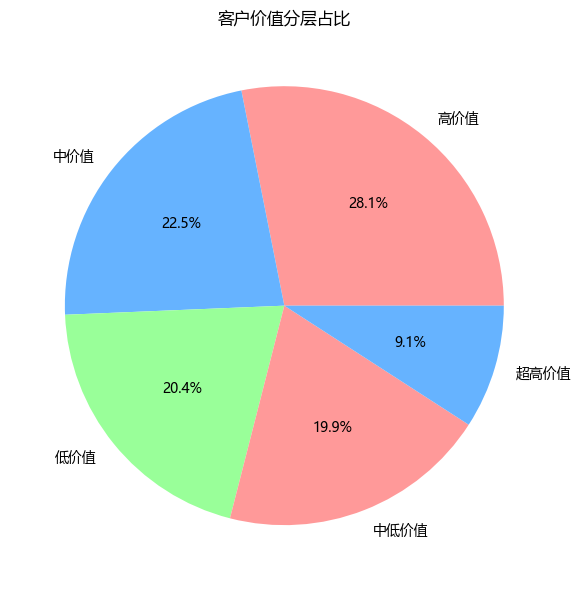

C:\Users\15383\AppData\Local\Temp\ipykernel_16572\2922451882.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_sales = customer_value.groupby('Tier')['Total_Spend'].sum().reset_index()


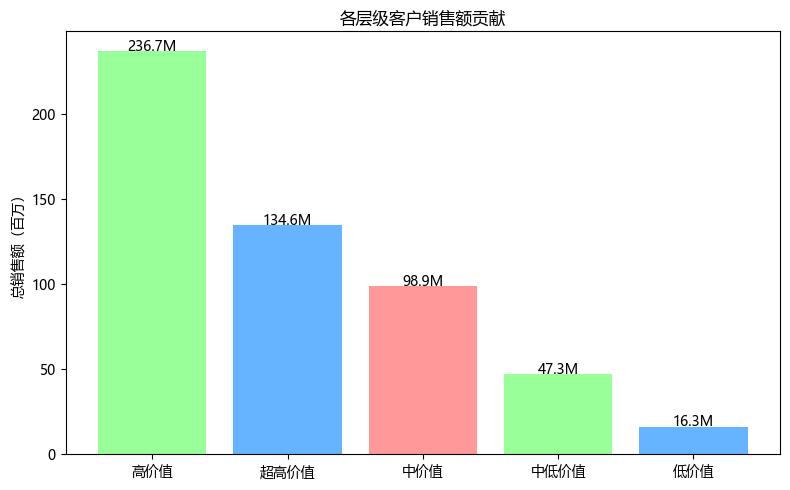

<Figure size 800x500 with 0 Axes>

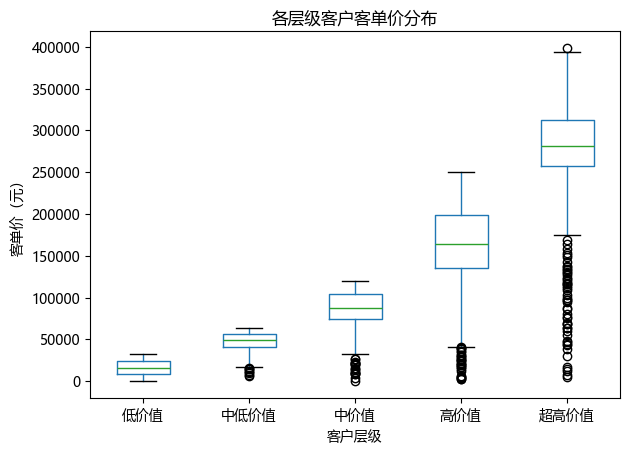

In [13]:
plt.figure(figsize=(6, 6))
plt.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('客户价值分层占比')
plt.tight_layout()
plt.show()

# 各层级销售额贡献（柱状图）
tier_sales = customer_value.groupby('Tier')['Total_Spend'].sum().reset_index()
tier_sales = tier_sales.sort_values('Total_Spend', ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(tier_sales['Tier'], tier_sales['Total_Spend'] / 1e6, color=['#99ff99','#66b3ff','#ff9999'])
plt.ylabel('总销售额（百万）')
plt.title('各层级客户销售额贡献')
for i, v in enumerate(tier_sales['Total_Spend'] / 1e6):
    plt.text(i, v + 0.2, f'{v:.1f}M', ha='center')
plt.tight_layout()
plt.show()

# 各层级客单价对比（箱线图）
df_with_tier = df.merge(customer_value[['Customer', 'Tier']], left_on='Customer Name', right_on='Customer', how='left')

plt.figure(figsize=(8, 5))
df_with_tier.boxplot(column='Sales', by='Tier', grid=False)
plt.title('各层级客户客单价分布')
plt.suptitle('')
plt.xlabel('客户层级')
plt.ylabel('客单价（元）')
plt.tight_layout()
plt.show()

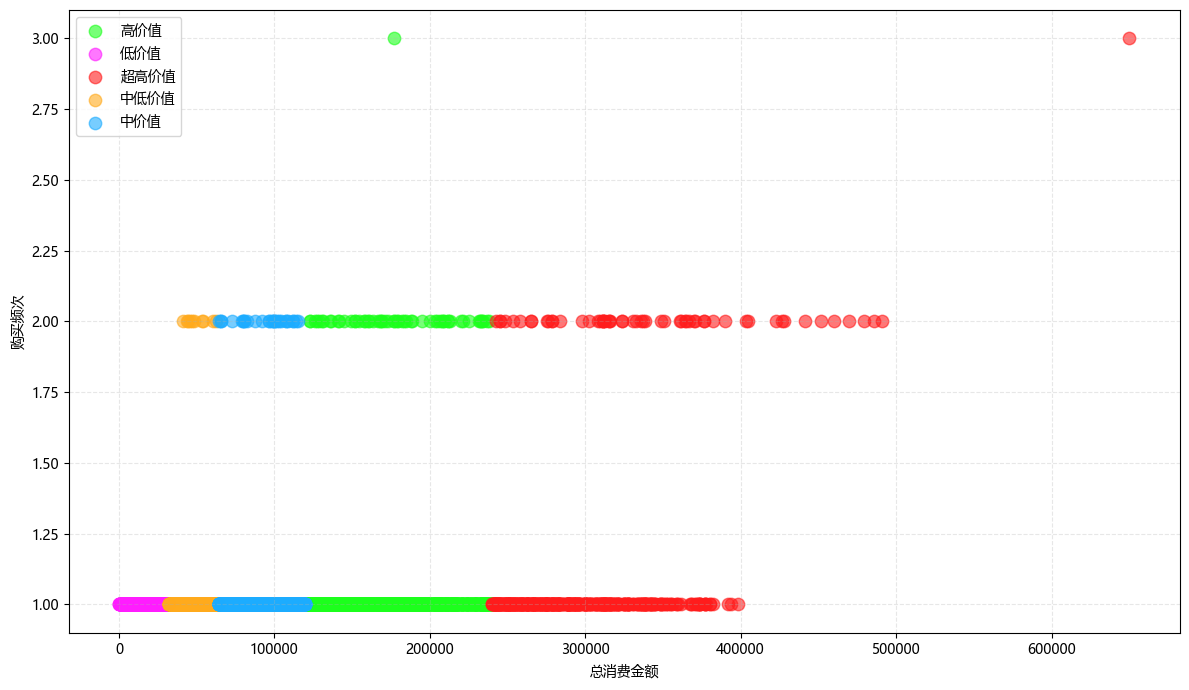

In [35]:
customer_data = df.groupby('Customer Name').agg({
    'Sales': 'sum',
    'Order ID': 'count'
}).reset_index()
customer_data.columns = ['Customer', 'Total_Spend', 'Frequency']


bins = [0, 32000, 64000, 120000, 240000, customer_data['Total_Spend'].max()]
labels = ['低价值', '中低价值', '中价值', '高价值', '超高价值']
customer_data['Tier'] = pd.cut(customer_data['Total_Spend'], bins=bins, labels=labels)

# 颜色映射
colors = {'低价值': '#ff1cff', '中低价值': '#ffaa1c', 
          '中价值': '#1cacff', '高价值': '#1cff1c', '超高价值': '#ff1c1c'}

plt.figure(figsize=(12, 7))
for tier in customer_data['Tier'].unique():
    subset = customer_data[customer_data['Tier'] == tier]
    plt.scatter(subset['Total_Spend'], subset['Frequency'], 
                label=tier, color=colors.get(tier, 'gray'), alpha=0.6, s=80)

plt.xlabel('总消费金额')
plt.ylabel('购买频次')
plt.title('')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

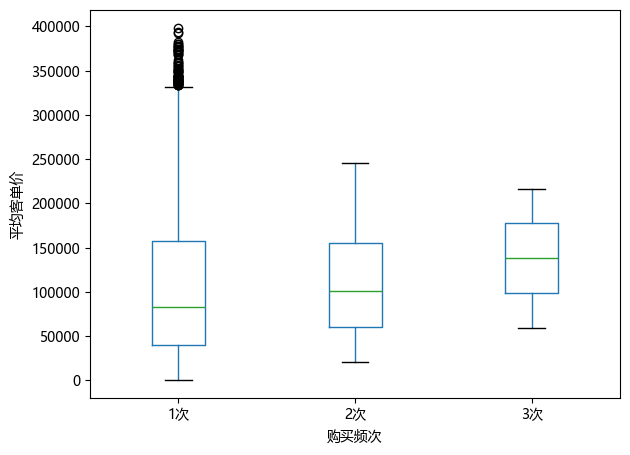

In [37]:
# 计算每个客户的平均客单价
customer_avg = df.groupby('Customer Name').agg({
    'Sales': 'mean',
    'Order ID': 'count'
}).rename(columns={'Sales': 'Avg_Order_Value', 'Order ID': 'Frequency'}).reset_index()

customer_avg['Freq_Group'] = customer_avg['Frequency'].apply(
    lambda x: '1次' if x == 1 else '2次' if x == 2 else '3次'
)

#  画箱线图
plt.figure(figsize=(8, 6))
customer_avg.boxplot(column='Avg_Order_Value', by='Freq_Group', grid=False)
plt.title('')
plt.suptitle('')
plt.xlabel('购买频次')
plt.ylabel('平均客单价')
plt.tight_layout()
plt.show()

城市销售额TOP10
           City         Sales  Profit_Margin  Avg_Order_Value  Order ID
2     Bangalore 29,989,840.85          14.73       114,903.60       261
13      Lucknow 29,901,483.40          15.13       114,565.07       261
9      Guwahati 29,606,888.90          15.16       101,047.40       293
4    Chandigarh 29,331,057.35          14.92       106,271.95       276
11       Jaipur 29,319,402.90          14.85       112,334.88       261
1      Amritsar 28,746,184.20          14.62       115,912.03       248
18        Surat 28,532,934.65          15.05       109,321.59       261
15        Patna 27,702,815.20          14.91       107,375.25       258
3   Bhubaneswar 27,088,786.45          15.03       108,790.31       249
17       Ranchi 26,948,513.25          15.26       115,658.86       233


C:\Users\15383\AppData\Local\Temp\ipykernel_24032\2647783563.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(city_top10['City'], rotation=45)


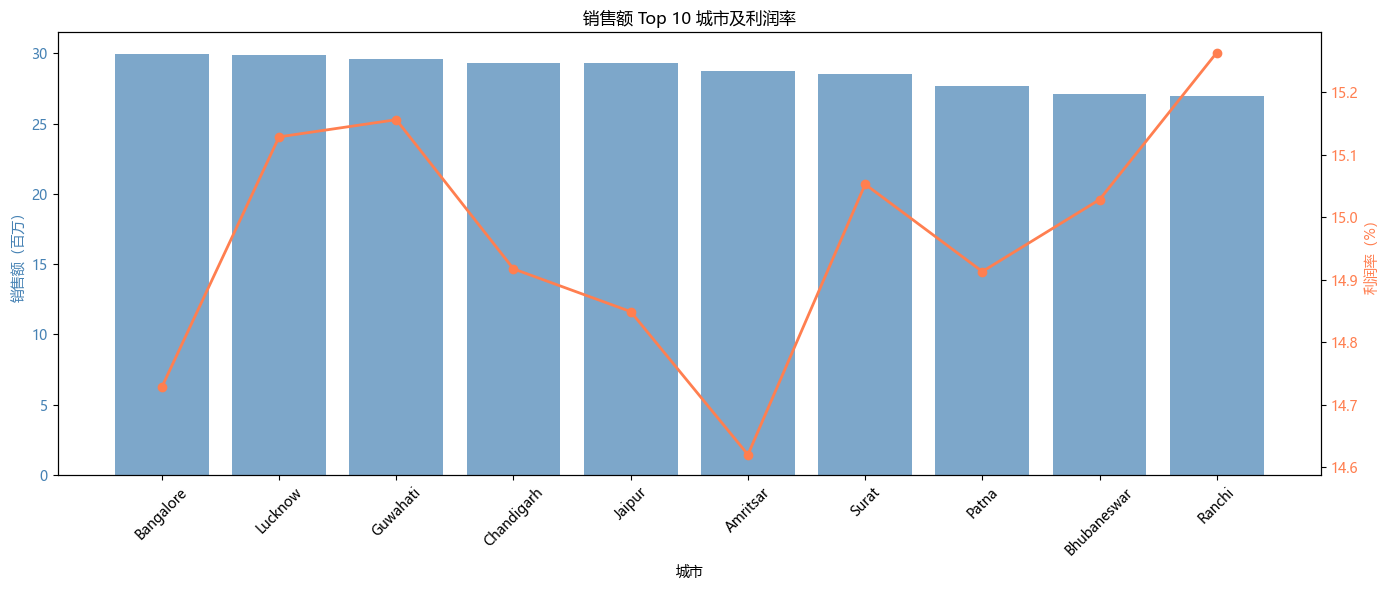

In [56]:
# 城市级汇总
city_summary = df.groupby('City').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'count',
    'Quantity': 'sum'
}).reset_index()

city_summary['Profit_Margin'] = (city_summary['Profit'] / city_summary['Sales']) * 100
city_summary['Avg_Order_Value'] = city_summary['Sales'] / city_summary['Order ID']
city_summary = city_summary.sort_values('Sales', ascending=False)

city_top10 = city_summary.head(10)

print("城市销售额TOP10")
print(city_top10[['City', 'Sales', 'Profit_Margin', 'Avg_Order_Value', 'Order ID']].to_string(float_format=lambda x: f'{x:,.2f}'))

# 可视化： 城市销售额 + 利润率双轴图
fig, ax1 = plt.subplots(figsize=(14, 6))

# 柱状图：销售额
ax1.bar(city_top10['City'], city_top10['Sales'] / 1e6, color='steelblue', alpha=0.7, label='销售额')
ax1.set_xlabel('城市')
ax1.set_ylabel('销售额（百万）', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_title('销售额 Top 10 城市及利润率')
ax1.set_xticklabels(city_top10['City'], rotation=45)

# 折线图：利润率（双轴）
ax2 = ax1.twinx()
ax2.plot(city_top10['City'], city_top10['Profit_Margin'], color='coral', marker='o', linewidth=2, label='利润率')
ax2.set_ylabel('利润率（%）', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

plt.tight_layout()
plt.show()


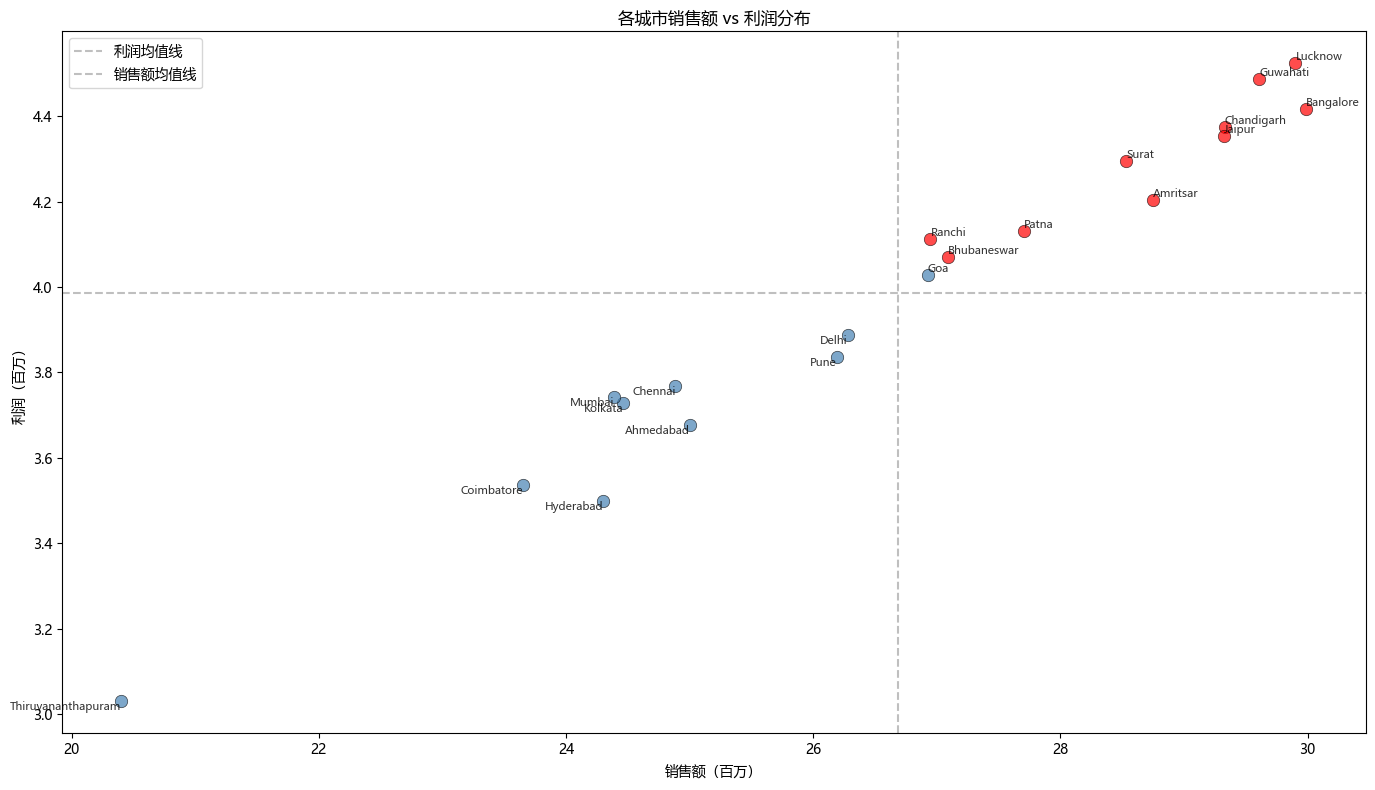

In [31]:
# 汇总所有城市
city_scatter = df.groupby('City').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()
city_scatter['Profit_Margin'] = (city_scatter['Profit'] / city_scatter['Sales']) * 100


#区分top10城市
city_scatter = city_scatter.sort_values('Sales', ascending=False).reset_index(drop=True)
city_scatter['Rank'] = city_scatter.index + 1
city_scatter['Color'] = city_scatter['Rank'].apply(lambda x: 'red' if x <= 10 else 'steelblue')

# 画散点图
fig, ax = plt.subplots(figsize=(14, 8))
for _, row in city_all.iterrows():
    plt.scatter(row['Sales'] / 1e6, row['Profit'] / 1e6, 
                color=row['Color'], s=80, alpha=0.7, 
                edgecolors='black', linewidth=0.5)


# 标注所有城市（错开方向）
for i, row in city_scatter.iterrows():
    x = row['Sales'] / 1e6
    y = row['Profit'] / 1e6
    # 根据位置动态调整标签方向
    if x > avg_sales/1e6 and y > avg_profit/1e6:
        ha, va = 'left', 'bottom'      
    elif x > avg_sales/1e6 and y <= avg_profit/1e6:
        ha, va = 'left', 'top'         
    elif x <= avg_sales/1e6 and y > avg_profit/1e6:
        ha, va = 'right', 'bottom'    
    else:
        ha, va = 'right', 'top'        
    ax.annotate(row['City'], (x, y), fontsize=8, ha=ha, va=va, alpha=0.8)
# 均线
ax.axhline(y=avg_profit/1e6, color='gray', linestyle='--', alpha=0.5, label='利润均值线')
ax.axvline(x=avg_sales/1e6, color='gray', linestyle='--', alpha=0.5, label='销售额均值线')

ax.set_xlabel('销售额（百万）')
ax.set_ylabel('利润（百万）')
ax.set_title('各城市销售额 vs 利润分布')
ax.legend()
plt.tight_layout()
plt.show()
